# Chapter 3.2 비지도학습

## 진행 방식

- 교재 개념을 먼저 설명
- 실습파일 기반 실습 진행
- 오늘의 주제: 
  - 비지도학습
    - 군집: K-means
    - 차원축소: PCA (주성분분석)

## 비지도학습

- 레이블(정답)이 없는 상태에서 훈련시키는 방식
  - 군집과 차원축소가 있음
- 군집 clustering
  - 각 데이터의 유사성(measure: distance)을 측정
  - 유사성이 높은(low distance) 데이터끼리 집단(군집, 혹은 클러스터)로 분류 (데이터 그룹화)
  - 주요 알고리즘: K-Means
  - 예: 고객 유형 분류에 따른 맞춤형 마케팅 전략
- 차원축소 dimensionality reduction
  - 데이터를 표현하는 차원(특성)을 줄여 데이터를 줄이는 방식
  - 예: 상관이 높은 특성들을 묶어 하나의 차원으로 표현하여 데이터 압축, 차원에 의한 연산부담 경감

## 유사도 (distance)

- 유클리드 거리
- 맨해튼 거리
- 민코프스키 거리
- 코사인 유사도 등
- 각각 자료에 기반한 수학적 정의가 존재하나 본 텍스트의 범위는 아님

# 3.2.1 K-means clustering (K-평균 군집화)

## 알고리즘 개요

- 입력받은 데이터를 그룹으로 묶는 알고리즘
  - 적합한 그룹 수를 미리 추측할 수 있을 때 사용하면 유용함 (예: 성별 --> 2, 연령대 --> 10 등)
- 레이블이 없는 데이터를 입력받아 각 데이터에 레이블(그룹)을 할당
- 학습과정
    1. 중심점 선택: 랜덤하게 그룹 수 (K) 만큼의 초기 중심점(centroid) 선택
    2. 클러스터 할당: 각 centroid들과 개별 데이터의 거리를 측정 --> 가장 가까운 centroid에 데이터를 할당 assign
    3. 새로운 중심점 선택: 각 클러스터에 새로운 중심점 계산함
    4. 범위 확인 (convergence): 새 중심점 변화가 더 이상 없으면 (convergence) 종료. 아니면 2-3 과정을 반복

![fig3-27](figures/fig3-27.png)

## K-means 가 적합하지 않은 경우

- 데이터가 비선형일 경우
![fig3-28](figures/fig3-28.png)

- 군집 크기가 다를 경우
![fig3-29](figures/fig3-29.png)

- 군집별 밀도(density)와 거리가 다를 때
![fig3-30](figures/fig3-30.png)

## 실습

- K-means clustering은 비슷한 데이터끼리 묶는 군집화의 대표 방법론
- 실습에서는 `sales data.csv`를 사용
- 핵심은 **전처리 후 엘보우 곡선으로 적절한 k를 가늠하는 것**


## 실습

실습 주제:

- 데이터 로드
- 범주형 변수 원-핫 인코딩
- Min-Max 정규화
- inertia 계산과 엘보우 곡선 확인

![fig3-31.png](figures/fig3-31.png)

In [1]:
#3.2.1 K=평균 군집화

In [3]:
import pandas as pd # 데이터 분석을 위한 라이브러리인 pandas를 pd라는 별칭으로 가져옴
from sklearn.preprocessing import MinMaxScaler # 데이터의 범위를 0과 1 사이로 조정하는 MinMaxScaler 클래스를 sklearn.preprocessing에서 가져옴
from sklearn.cluster import KMeans # KMeans 군집화 알고리즘을 sklearn.cluster에서 가져옴, 이 알고리즘은 데이터를 K개의 군집으로 나누는 데 사용됨
import matplotlib.pyplot as plt # 데이터 시각화를 위한 라이브러리인 matplotlib.pyplot을 plt라는 별칭으로 가져옴

In [7]:
data = pd.read_csv('../data/sales data.csv') # CSV 파일을 읽어와서 DataFrame으로 저장, '../chap03/data/sales data.csv'는 CSV 파일의 경로를 나타냄, 이 파일에는 판매 데이터가 포함되어 있을 것으로 예상됨
# data = pd.read_csv('../chap03/data/sales data.csv')
data.head() # DataFrame의 처음 5행을 출력하여 데이터의 구조와 내용을 확인함

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [8]:
categorical_features = ['Channel', 'Region'] # 범주형 특성의 이름을 리스트로 저장, 'Channel'과 'Region'은 데이터셋에서 범주형 특성으로 사용되는 열의 이름을 나타냄
continuous_features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'] # 연속형 특성의 이름을 리스트로 저장, 이 열들은 데이터셋에서 연속적인 수치 데이터를 포함하는 열의 이름을 나타냄

for col in categorical_features: # 범주형 특성에 대해 반복하여 각 특성을 원-핫 인코딩으로 변환
    dummies = pd.get_dummies(data[col], prefix=col) # pd.get_dummies() 함수를 사용하여 col 열의 범주형 데이터를 원-핫 인코딩으로 변환, prefix=col은 생성된 더미 변수의 열 이름에 col 값을 접두사로 추가함
    data = pd.concat([data, dummies], axis=1) # 원-핫 인코딩으로 생성된 더미 변수들을 기존 데이터프레임에 열 방향으로 추가함, pd.concat() 함수는 두 데이터프레임을 연결하는 데 사용되며, axis=1은 열 방향으로 연결하도록 지정함
    data.drop(col, axis=1, inplace=True) # 원래의 범주형 열을 데이터프레임에서 제거함, axis=1은 열 방향으로 제거하도록 지정하며, inplace=True는 원본 데이터프레임을 직접 수정하도록 설정함
data.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2,Region_1,Region_2,Region_3
0,12669,9656,7561,214,2674,1338,False,True,False,False,True
1,7057,9810,9568,1762,3293,1776,False,True,False,False,True
2,6353,8808,7684,2405,3516,7844,False,True,False,False,True
3,13265,1196,4221,6404,507,1788,True,False,False,False,True
4,22615,5410,7198,3915,1777,5185,False,True,False,False,True


## 연속형 데이터와 명목형 데이터의 분류

- `Channel`, `Region`은 범주형이므로 그대로 거리 계산에 넣기 어려움
- 그래서 원-핫 인코딩으로 각 범주를 별도 열로 바꿈
- Scaling: 이후 정규화를 해서 특정 변수의 스케일이 군집 중심을 지배하지 않게 함


In [9]:
# Scaling

mms = MinMaxScaler() # MinMaxScaler 객체를 생성하여 mms에 저장, 이 객체는 데이터의 범위를 0과 1 사이로 조정하는 데 사용됨
mms.fit(data) # MinMaxScaler 객체 mms를 사용하여 데이터에 대한 스케일링을 학습, 이 과정에서 데이터의 최소값과 최대값을 계산하여 나중에 데이터를 0과 1 사이로 조정하는 데 사용됨
data_transformed = mms.transform(data) # MinMaxScaler를 사용하여 데이터를 0과 1 사이로 조정한 결과를 data_transformed에 저장, 이 배열은 원래 데이터의 각 특성 값이 최소값과 최대값을 기준으로 조정된 형태로 변환된 데이터를 포함함

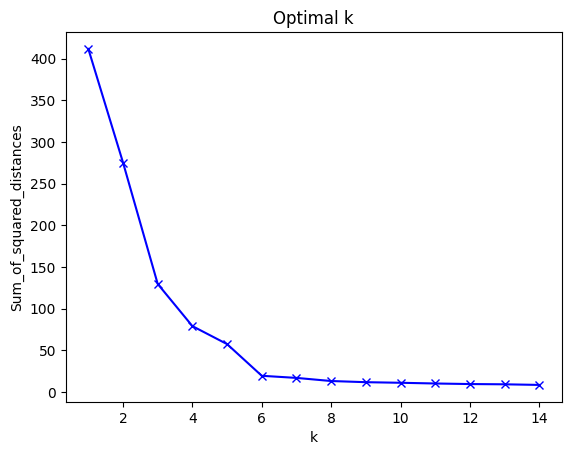

In [10]:
# 적절한 K 찾기

Sum_of_squared_distances = []
K = range(1,15) # K의 후보 범위를 1부터 14까지 설정하여 K-평균 군집화에서 사용할 군집의 수를 나타냄
for k in K:
    km = KMeans(n_clusters=k) # KMeans 객체를 생성하여 km에 저장, n_clusters=k는 군집의 수를 k로 설정함
    km = km.fit(data_transformed) # KMeans 알고리즘을 사용하여 data_transformed 데이터를 k개의 군집으로 나누는 작업을 수행함, 이 과정에서 군집 중심과 각 데이터 포인트 간의 거리를 계산하여 군집을 형성함
    Sum_of_squared_distances.append(km.inertia_) # KMeans 객체 km의 inertia_ 속성은 군집 내의 데이터 포인트와 군집 중심 간의 거리의 제곱합(SSD: Sum of Squared Distances)을 나타냄, 이 값을 Sum_of_squared_distances 리스트에 추가하여 각 k에 대한 군집화의 품질을 평가하는 데 사용됨

plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Optimal k')
plt.show()

## SSD의 정의

$$ SSD := \sum_{x,y}(I_1(x,y) - I_2 (x,y))^2 $$

## K-means 해석

- k가 커질수록 inertia는 계속 감소
- 따라서 단순히 가장 작은 값을 고르는 것이 아니라, **감소 폭이 급격히 줄어드는 지점**을 찾는 것이 엘보우 메서드
- 본 예제에서는 K=5 정도가 적정


# 3.2.3 밀도 기반 군집 분석(DBSCAN)

## 개요

- 고차원 데이터를 바로 보면 구조가 잘 보이지 않음
- PCA로 2차원으로 줄인 뒤 DBSCAN으로 군집과 노이즈를 해석
- 실습에서는 `credit card.csv`를 사용

## DBSCAN: Density-Based Spatial Clustering of Applications with Noise

- 일정 밀도 이상을 가진 데이터를 기준으로 군집을 형성하는 방식
- 유용한 케이스
  - K-means 와 달리 사전에 클러스터 갯수 K를 알지 못할 때
  - 데이터에 이상치(outlier)가 많이 포함되어 있을 때


![fig3-35](figures/fig3-35.png)

- 특성
  - noise 영향이 적음

![fig3-37](figures/fig3-37.png)

  - K-means보다 연산량이 많음
  - K-means에서 처리 못하는 오목/볼록 파트를 처리하는데 유용함

![fig3-36](figures/fig3-36.png)


## 알고리즘

### Step 1. 중심점 결정

- 어떤 점 P1 에서 거리 $$\epsilon$$ 내에 점이 m(minPts) 개가 있으면 하나의 군집으로 인식하는 것으로 정의
  - 이때 P1 은 중심점 core point
  - minPts 는 군집 인식 판단 기준
- 아래 예에서는 monPts=3 일 경우 군집으로 판단될 수 있음 (Pts = 4 > minPts 이기 때문)

![fig3-38](figures/fig3-38.png)

### Step 2. 군집 확장

- 새로운 군집을 형성
- 아래 예에서는 새로운 P2에 대해서 군집조건을 만족하기 때문에 새로운 군집을 생성함

![fig3-39](figures/fig3-39.png)

- 상기 군집을 하나로 합침

![fig3-40](figures/fig3-40.png)

### Step 3. Step 1-2 반복

- 멈춤 조건: 더 이상 중심점을 추가 정의할 수 없게 될 때

### Step 4. 노이즈 정의

- 조건: 어떤 군집에도 포함되지 않은 데이터





# 3.2.3 주성분분석 (PCA)

# 개요

- PCA (Principal Component Analysis): 고차원의 데이터의 차원을 축소하는 알고리즘
- 여러 데이터가 모여 하나의 분포를 이룰 때 이 분포의 주성분을 분석하는 방법론
- 아래의 예: 여러 차원의 데이터를 $$e_1, e_2$$ 두 차원으로 줄여 분석

![fig3-41](figures/fig3-41.png)

## PCA, DBSCAN 실습

### 주 내용

- 데이터 정리와 결측치 처리
- 표준화와 정규화
- PCA 2차원 투영
- DBSCAN `min_samples` 변화 비교

### 전체 과정

![fig3-42](figures/fig3-42.png)


In [11]:
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt 
  
from sklearn.cluster import DBSCAN # DBSCAN 군집화 알고리즘을 sklearn.cluster에서 가져옴, 이 알고리즘은 밀도 기반 군집화를 수행하는 데 사용됨
from sklearn.preprocessing import StandardScaler # 데이터의 평균을 0으로, 표준 편차를 1로 조정하는 StandardScaler 클래스를 sklearn.preprocessing에서 가져옴
from sklearn.preprocessing import normalize  # 데이터의 각 샘플을 개별적으로 정규화하여 벡터의 크기를 1로 만드는 normalize 함수를 sklearn.preprocessing에서 가져옴
from sklearn.decomposition import PCA # PCA(주성분 분석) 클래스를 sklearn.decomposition에서 가져옴, 이 클래스는 고차원 데이터를 저차원으로 축소하는 데 사용됨

#### df.fillna(method='ffill')

앞의 값으로 결측치가 채워짐

![fig3-43](figures/fig3-43.png)



In [13]:
X = pd.read_csv('../data/credit card.csv') 
#X = pd.read_csv('../chap03/data/credit card.csv') 
X = X.drop('CUST_ID', axis = 1) # CUST_ID 열을 데이터프레임에서 제거함, axis=1은 열 방향으로 제거하도록 지정함을 뜻함
X.fillna(method ='ffill', inplace = True) # 결측치를 전방의 값으로 채움, inplace=True는 원본 데이터프레임을 직접 수정하도록 설정함
print(X.head())

       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0    40.900749           0.818182      95.40              0.00   
1  3202.467416           0.909091       0.00              0.00   
2  2495.148862           1.000000     773.17            773.17   
3  1666.670542           0.636364    1499.00           1499.00   
4   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000                          0.000000   
2                

/var/folders/cn/dn34sbdj0wl17p35ccbk3nbw0000gn/T/ipykernel_63980/4256381398.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X.fillna(method ='ffill', inplace = True) # 결측치를 전방의 값으로 채움, inplace=True는 원본 데이터프레임을 직접 수정하도록 설정함


In [14]:
# PCA: 2차원으로 축소

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # StandardScaler를 사용하여 X 데이터를 평균이 0이고 표준 편차가 1이 되도록 스케일링한 결과를 X_scaled에 저장, 이 과정은 PCA를 적용하기 전에 데이터의 스케일을 조정하는 데 사용됨
X_normalized = normalize(X_scaled) # normalize 함수를 사용하여 X_scaled 데이터를 정규화하여 각 샘플의 벡터 크기를 1로 조정한 결과를 X_normalized에 저장, 이 과정은 PCA를 적용하기 전에 데이터의 방향을 유지하면서 크기를 조정하는 데 사용됨
X_normalized = pd.DataFrame(X_normalized)
pca = PCA(n_components = 2) # PCA 객체를 생성하여 pca에 저장, n_components=2는 PCA를 사용하여 데이터를 2차원으로 축소하도록 설정함
X_principal = pca.fit_transform(X_normalized) # PCA 객체 pca를 사용하여 X_normalized 데이터를 2차원으로 축소한 결과를 X_principal에 저장, 이 과정에서 PCA는 데이터의 분산을 최대한 보존하면서 고차원 데이터를 저차원으로 변환함
X_principal = pd.DataFrame(X_principal) 
X_principal.columns = ['P1', 'P2'] 
print(X_principal.head())

         P1        P2
0 -0.489949 -0.679976
1 -0.519099  0.544827
2  0.330633  0.268879
3 -0.481656 -0.097611
4 -0.563512 -0.482506


## 여기서 중요한 메시지

- PCA는 군집 알고리즘이 아니라 **구조를 보이게 만드는 표현 변환**
- 원래 고차원 데이터였던 것을 2차원 좌표 `P1`, `P2`로 바꿔,
  이후 DBSCAN 결과를 시각적으로 읽을 수 있게 함


In [15]:
db_default = DBSCAN(eps = 0.0375, min_samples = 3).fit(X_principal) # DBSCAN 객체를 생성하여 db_default에 저장, eps=0.0375는 이웃을 정의하는 반경의 크기를 설정하고, min_samples=3은 핵심 포인트로 간주되기 위해 필요한 최소 이웃 수를 설정함. fit() 메서드를 사용하여 X_principal 데이터에 DBSCAN 알고리즘을 적용하여 군집화를 수행함
labels = db_default.labels_ # DBSCAN 알고리즘이 각 데이터 포인트에 할당한 군집 레이블을 labels에 저장, 이 배열은 각 데이터 포인트가 속한 군집의 번호를 나타내며, -1은 노이즈로 간주되는 포인트를 나타냄

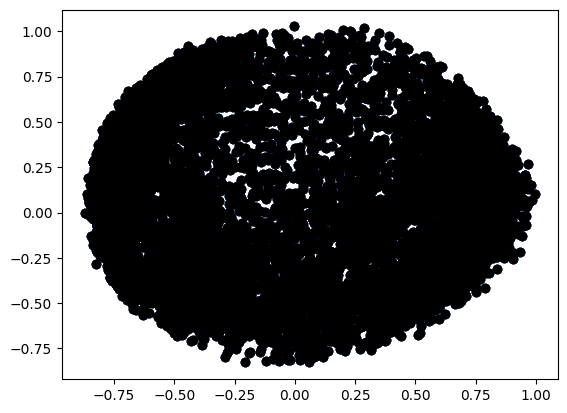

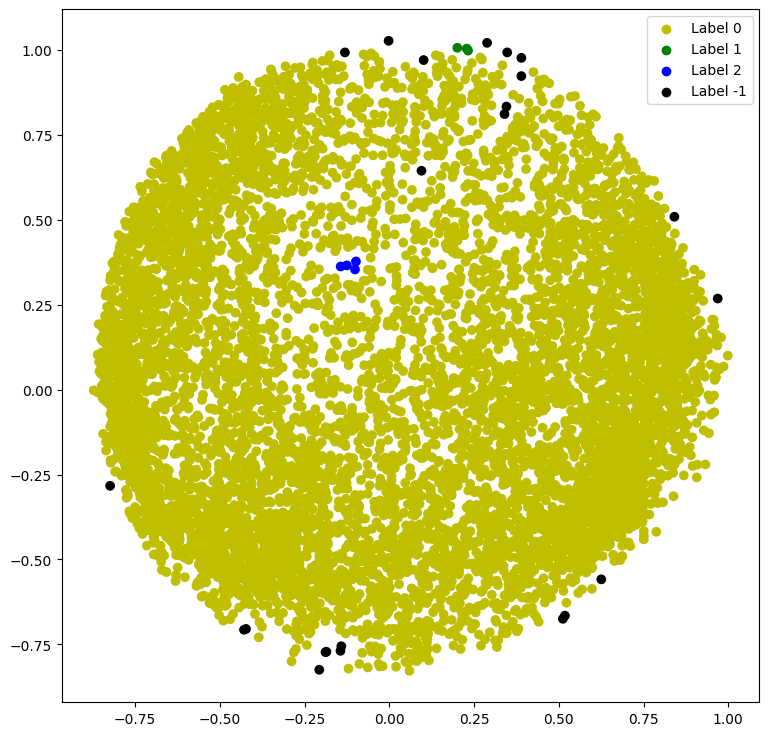

In [16]:
colours = {} # 군집 레이블에 대응하는 색상을 저장하는 딕셔너리를 생성하여 colours에 저장, 이 딕셔너리는 군집 레이블을 키로 사용하고 해당 군집에 할당할 색상을 값으로 저장하는 데 사용됨
colours[0] = 'y' 
colours[1] = 'g'
colours[2] = 'b'
colours[-1] = 'k'
  
cvec = [colours[label] for label in labels] # labels 배열의 각 요소에 대해 해당 레이블에 대응하는 색상을 colours 딕셔너리에서 찾아서 cvec 리스트에 저장, 이 리스트는 각 데이터 포인트가 속한 군집의 색상을 나타냄
  
r = plt.scatter(X_principal['P1'], X_principal['P2'], color ='y'); 
g = plt.scatter(X_principal['P1'], X_principal['P2'], color ='g'); 
b = plt.scatter(X_principal['P1'], X_principal['P2'], color ='b'); 
k = plt.scatter(X_principal['P1'], X_principal['P2'], color ='k'); 
  
plt.figure(figsize =(9, 9)) 
plt.scatter(X_principal['P1'], X_principal['P2'], c = cvec) # X_principal의 P1과 P2 열을 사용하여 산점도를 그리고, cvec 리스트를 사용하여 각 데이터 포인트의 색상을 지정함. 이 산점도는 DBSCAN 알고리즘에 의해 형성된 군집을 시각적으로 나타내며, 각 군집은 다른 색상으로 표시됨
  
plt.legend((r, g, b, k), ('Label 0', 'Label 1', 'Label 2', 'Label -1'))
plt.show()

### 결과 해석

- 클러스터링이 제대로 되지 않았음 ==> 튜닝 필요
- 아래 예제에서는 minPts (min_samples) 를 3--> 50으로 변경

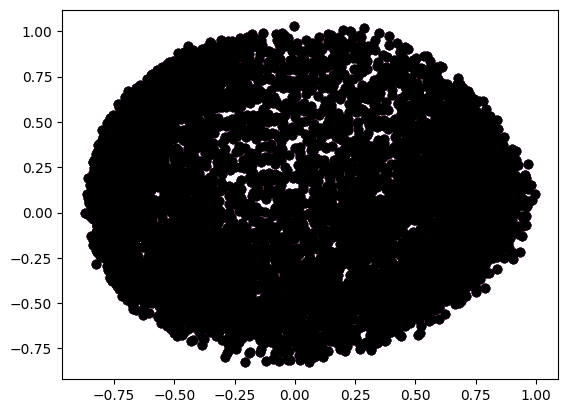

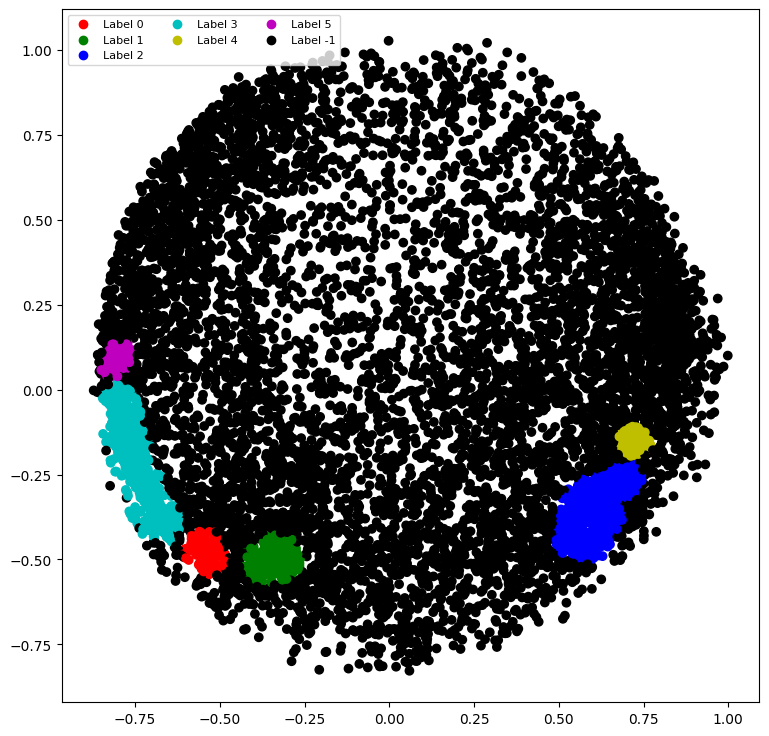

In [17]:
db = DBSCAN(eps = 0.0375, min_samples = 50).fit(X_principal) # 파라미터 튜닝: 3--> 50
labels1 = db.labels_

colours1 = {} 
colours1[0] = 'r'
colours1[1] = 'g'
colours1[2] = 'b'
colours1[3] = 'c'
colours1[4] = 'y'
colours1[5] = 'm'
colours1[-1] = 'k'
  
cvec = [colours1[label] for label in labels1] 
colors1 = ['r', 'g', 'b', 'c', 'y', 'm', 'k' ] 
  
r = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[0]) 
g = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[1]) 
b = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[2]) 
c = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[3]) 
y = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[4]) 
m = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[5]) 
k = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[6]) 
  
plt.figure(figsize =(9, 9)) 
plt.scatter(X_principal['P1'], X_principal['P2'], c = cvec) 
plt.legend((r, g, b, c, y, m, k), 
           ('Label 0', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label -1'), 
           scatterpoints = 1, 
           loc ='upper left', 
           ncol = 3, 
           fontsize = 8) 
plt.show()


### 튜닝2: minPts 50 --> 100

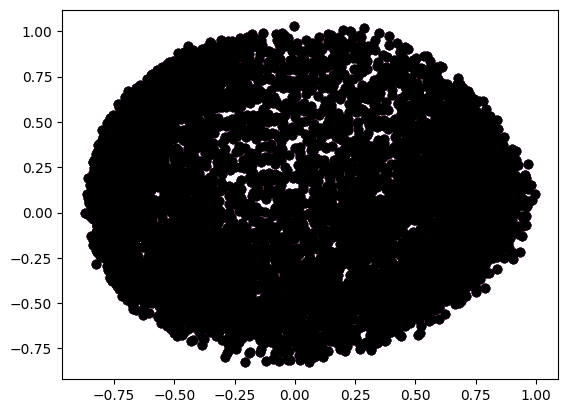

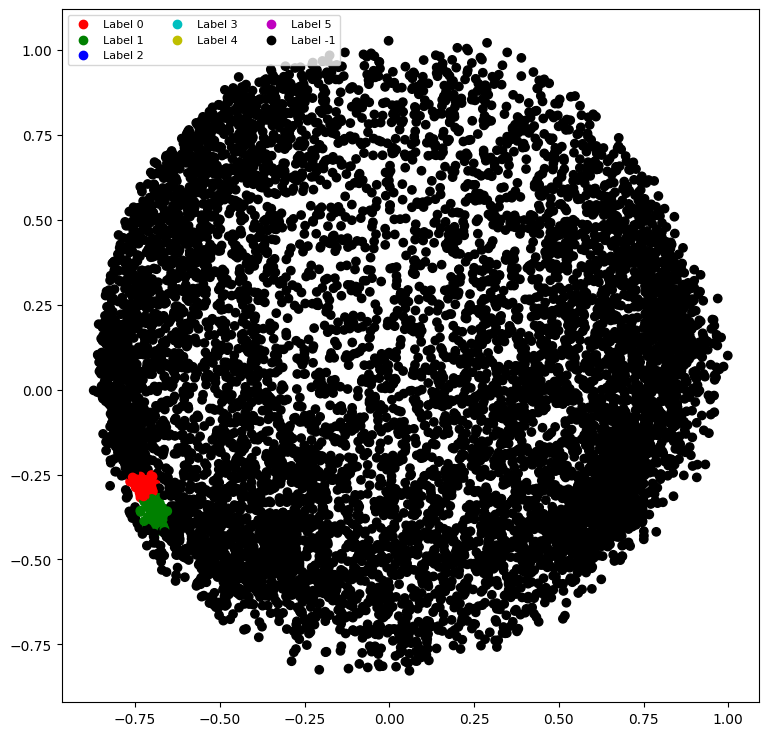

In [18]:
db = DBSCAN(eps = 0.0375, min_samples = 100).fit(X_principal)
labels1 = db.labels_

colours1 = {} 
colours1[0] = 'r'
colours1[1] = 'g'
colours1[2] = 'b'
colours1[3] = 'c'
colours1[4] = 'y'
colours1[5] = 'm'
colours1[-1] = 'k'
  
cvec = [colours1[label] for label in labels1] 
colors1 = ['r', 'g', 'b', 'c', 'y', 'm', 'k' ] 
  
r = plt.scatter(
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[0]) 
g = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[1]) 
b = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[2]) 
c = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[3]) 
y = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[4]) 
m = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[5]) 
k = plt.scatter( 
    X_principal['P1'], X_principal['P2'], marker ='o', color = colors1[6]) 
  
plt.figure(figsize =(9, 9)) 
plt.scatter(X_principal['P1'], X_principal['P2'], c = cvec) 
plt.legend((r, g, b, c, y, m, k), 
           ('Label 0', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label -1'), 
           scatterpoints = 1, 
           loc ='upper left', 
           ncol = 3, 
           fontsize = 8) 
plt.show()


## DBSCAN 파라미터 의 의미

- `min_samples`가 작으면 작은 밀도 집단도 군집으로 잡힘
- `min_samples`를 키우면 더 조밀한 집단만 남고 나머지는 노이즈로 밀려날 수 있음
- 즉 DBSCAN은 **군집 수를 정하는 방식**이 아니라, **얼마나 촘촘해야 군집으로 볼지 정하는 방식**에 가까움


# 정리

- K-means: k를 정하고 엘보우 곡선으로 적절한 군집 수를 가늠
- PCA: 고차원 데이터를 시각화 가능한 저차원으로 축소
- DBSCAN: 밀도 기반으로 군집과 노이즈를 함께 해석
